In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\datasets\Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
x=data.drop(columns=['Id','Species'])
y=data['Species']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm  import SVC
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [5]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.30,stratify=y)

In [6]:
model= SVC()
model.fit(x_train,y_train)

SVC()

In [7]:
y_pred= model.predict(x_test)

In [8]:
accuracy_score(y_test,y_pred)

0.9555555555555556

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(SVC(),x,y)

array([0.96666667, 0.96666667, 0.96666667, 0.93333333, 1.        ])

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


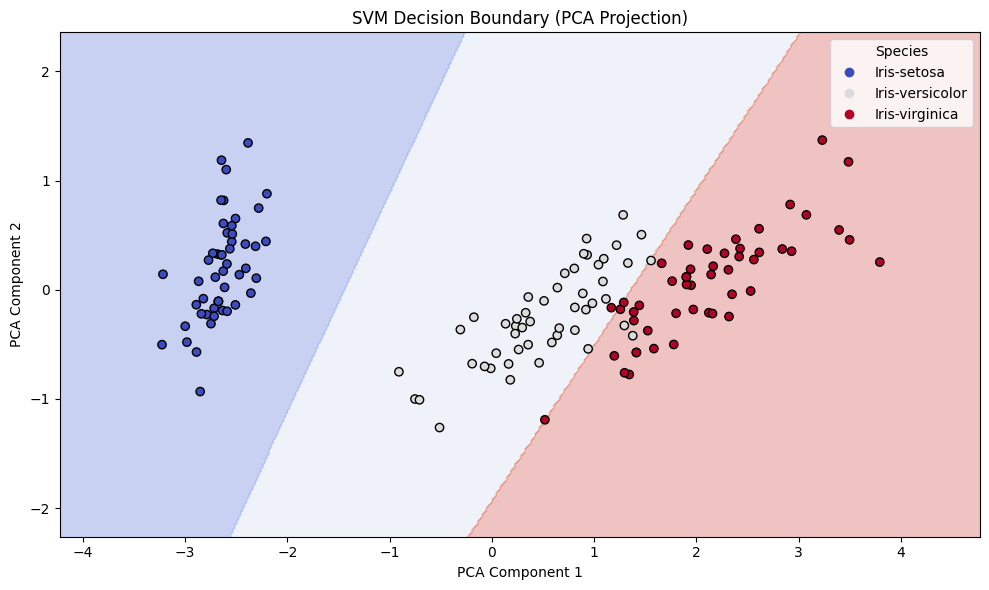

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\datasets\Iris.csv")  # Make sure Iris.csv is in the same directory
X = df.drop(columns=["Id", "Species"])
y = df["Species"]

# Encode species labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Train SVM classifier
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X_train, y_train)

# Predictions and evaluation
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Retrain SVM on PCA-reduced data for visualization
clf_pca = svm.SVC(kernel='linear', C=1)
clf_pca.fit(X_pca, y_encoded)

# Create a mesh grid


# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM Decision Boundary (PCA Projection)")

# Legend
legend_labels = le.inverse_transform(np.unique(y_encoded))
handles = [plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.coolwarm(i / 2), label=label)
           for i, label in zip(np.unique(y_encoded), legend_labels)]
plt.legend(handles=handles, title="Species")


plt.tight_layout()
plt.show()
